# Bias Analysis on H-R Diagram with Gaia DR3 data

```Authors: Paul Alvarez updated: 20260713```

This notebook retrieves a study about the bias in distance-parallax measures. The analyze use Gaia data (via Astroquery) for a selected region of the sky (e.g., Pleiades) and computes stellar absolute magnitudes from parallax measurements, including a discussion about Lutz–Kelker bias associated with estimating distances using the naive inverse-parallax approach (1/parallax), and examines how the resulting Hertzsprung–Russell diagram changes when Bayesian distance estimates are used instead (based on Bailer-Jones paper approach).

## Table of contents:
* [Required libraries](#Required-libraries)
* [Introduction](#Introduction)
    * [Calibration of Luminosity Systems](#Calibration_of_Luminosity_Systems)
* [Data: Collection and Description](#Data:_Collection_and_Description)
* [Naive Approuch: 1/parallax](#Naive_Approuch:_1/parallax)
* [Lutz-Kelker Bias](#lutz-kelker-bias)


## Required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

## Introduction 

### Calibration of Luminosity Systems

Lutz and Kelker (1973) analyzed the problem of star selection by imposing a “minimum limit” on observed parallax, which introduces a systematic error. Since instruments have errors, some stars that are actually outside this limit (further away) will be overestimated and included in the sample. At the same time, some stars that should be inside (closer) will be underestimated and excluded because, at greater distances, the volume of space is much larger; there are far more stars outside waiting to “sneak in” by error than there are stars inside that might be excluded. 


Geometric analysis at the boundary ($\pi'$) shows that since the geometry of space is not symmetric (stars are uniformly distributed throughout the universe, so the number of stars per parallax interval varies drastically as $1/\pi^4$). Mathematically, this means there is an overwhelmingly larger number of stars with smaller (more distant) true parallaxes. Thus, the vast majority of stars that register as $\pi'$ come from that enormous, textured cluster of distant stars that were pushed upward by measurement noise. Consequently, the average true parallax of those stars will always be less than the measured value $\pi'$.

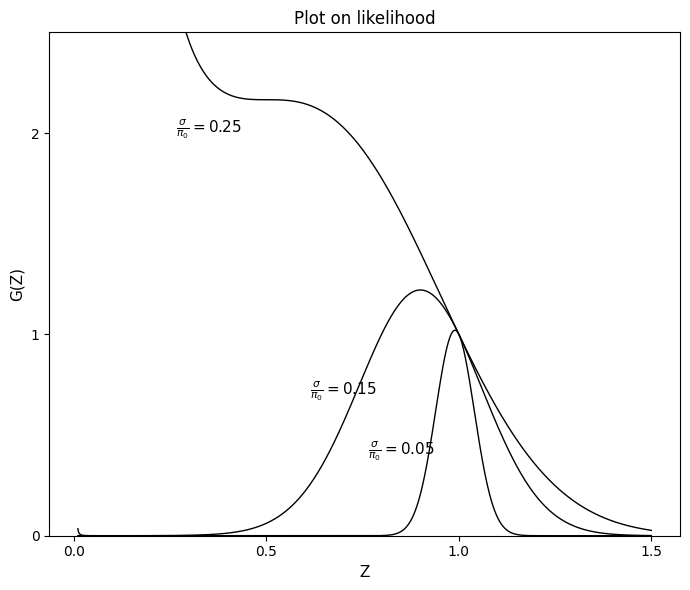

In [2]:
# Likelihood
def G(Z, s_p):
    """
    Z: X axis
    s_p: Y axis (sigma / pi_0)
    """
    # No division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        return (1 / Z**4) * np.exp(-((Z - 1)**2) / (2 * (s_p**2)))

Z = np.linspace(0.01, 1.5, 1000)
params = [0.25, 0.15, 0.05]

plt.figure(figsize=(7, 6))
for s_p in params:
    plt.plot(Z, G(Z, s_p), color='black', linewidth=1)

plt.ylim(0, 2.5)
plt.xlabel('Z', fontsize=11)
plt.ylabel('G(Z)', fontsize=11)
plt.xticks([0, 0.5, 1.0, 1.5])
plt.yticks([0, 1.0, 2.0])
plt.text(0.35, 2.0, r'$\frac{\sigma}{\pi_0}=0.25$', fontsize=11, ha='center')
plt.text(0.7, 0.7, r'$\frac{\sigma}{\pi_0}=0.15$', fontsize=11, ha='center')
plt.text(0.85, 0.4, r'$\frac{\sigma}{\pi_0}=0.05$', fontsize=11, ha='center')
plt.title(label="Plot on likelihood")
plt.tight_layout()
plt.show()

## Data: Collection and Description

To define the region of the GAIA data to be examined, we will use the celestial location of the Pleiades (M45) as a guide. Since it is a star cluster, we know that the stars formed at the same time and are all at the same distance from us, which results in less noise than other regions when using the stellar data for an HR diagram.

In [3]:
# Pleiades open cluster
ra_target = 56.75   
dec_target = 24.12 
radius_deg = 1

# Metadata for the study
query = f"""
SELECT
    source_id,
    ra,
    dec,
    parallax,
    parallax_error, 
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe,
    visibility_periods_used,
    astrometric_excess_noise,
    parallax_over_error
FROM gaiadr3.gaia_source
WHERE
    CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra_target}, {dec_target}, {radius_deg})
    ) = 1
    AND parallax > 0
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
"""

# Get the query results
job = Gaia.launch_job_async(query)
results_table = job.get_results()

# Convert table to dataframe
df_gaia = results_table.to_pandas()
print(f"Size of the sample: {len(df_gaia)} stars collected.")

INFO: Query finished. [astroquery.utils.tap.core]
Size of the sample: 19966 stars collected.


In [4]:
print("First records from the sample:")
print(df_gaia[['source_id', 'parallax', 'parallax_error', 'ruwe', 'phot_g_mean_mag']].head())

print("\nDescriptive statistics for the resulting sample:")
print(df_gaia[['parallax', 'parallax_error', 'ruwe']].describe())

First records from the sample:
           source_id  parallax  parallax_error      ruwe  phot_g_mean_mag
0  64874454510493440  7.391450        0.087295  1.025504        17.110922
1  64879432377203328  0.006256        0.217516  1.047584        18.428904
2  64879711550463872  0.115596        0.130499  1.000797        17.748634
3  64879780270367744  1.070050        0.191717  1.006613        18.233324
4  64906267331921792  0.572449        0.156406  0.913251        17.796642

Descriptive statistics for the resulting sample:
           parallax  parallax_error          ruwe
count  19966.000000    19966.000000  19966.000000
mean       1.163068        0.376157      1.097889
std        1.528277        0.407700      0.731691
min        0.000131        0.013005      0.751886
25%        0.357661        0.093014      0.982287
50%        0.708272        0.229894      1.019763
75%        1.332549        0.514376      1.062425
max       41.460972        3.794487     38.557499


## Naive approuch: 1/parallax

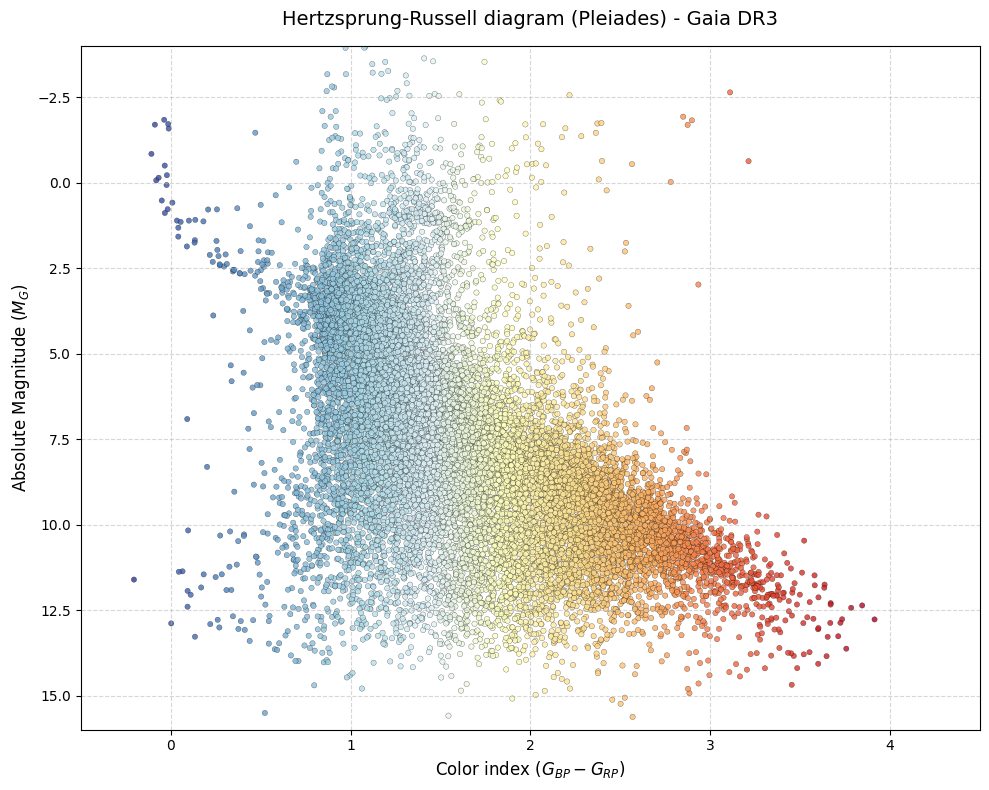

In [10]:
# Calculate the absolute g using the naive approach
pc_distance = 1000.0 / df_gaia['parallax']
df_gaia['absolute_g'] = df_gaia['phot_g_mean_mag'] - 5.0 * np.log10(pc_distance) + 5.0

# Color idx: BP - RP
df_gaia['bp_rp'] = df_gaia['phot_bp_mean_mag'] - df_gaia['phot_rp_mean_mag']

# HR diagrama
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_gaia['bp_rp'], df_gaia['absolute_g'], c=df_gaia['bp_rp'], cmap='RdYlBu_r', 
                s=15, edgecolor='black', linewidths=0.2, alpha=0.8)

plt.gca().invert_yaxis()
plt.title('Hertzsprung-Russell diagram (Pleiades) - Gaia DR3', fontsize=14, pad=15)
plt.xlabel('Color index ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.5, 4.5)
plt.ylim(16, -4) 
plt.tight_layout()
plt.show()

Observamos que, a pesar de que el diagrama HR presenta la forma general esperada (esto es, las estrellas de mayor luminosidad están situadas en la parte superior del diagrama, y las estrellas con una temperatura superficial elevada están en el lado izquierdo), se aprecia un gráfico con mayor dispersión a los diagramas típicos de luminosidad y temperatura efectiva. 

En concreto, podemos apreciar como hay una agrupación de estrellas con menor magnitud absoluta y indice de color. Para diagnosticar lo que está sucediendo, denotemos por $f = \frac{\sigma_{\varpi}}{\varpi}$ a la fracción de error del paralaje (referida en este contexto, solo en base a la medición de la muestra). Luego, si tomamos su inverso, obtenemos la relación señal-ruido de la medición del paralaje, esto es:

$$
f = \frac{\sigma_{\varpi}}{\varpi} = \frac{1}{\mathrm{SNR}},
\qquad
\mathrm{SNR} = \frac{\varpi}{\sigma_{\varpi}}.
$$

Ahora, según lo analizado por Lutz and Kelker (1973) y Bailer-Jones (2015), el error de la medición del paralaje comienza a ser inestable como estimador de la distancia, cuando $f > 0.2$, lo que se traduce en una relación señal-ruido permitida de $\mathrm{SNR} > 5$. 

In [6]:
df_gaia["snr"] = (df_gaia["parallax_error"] / df_gaia["parallax"])
highly_biased_measures = (df_gaia["snr"] <= 5).mean() 
print(f"Percentage of distances which are highly biased: {highly_biased_measures * 100}")

Percentage of distances which are highly biased: 96.09836722428128


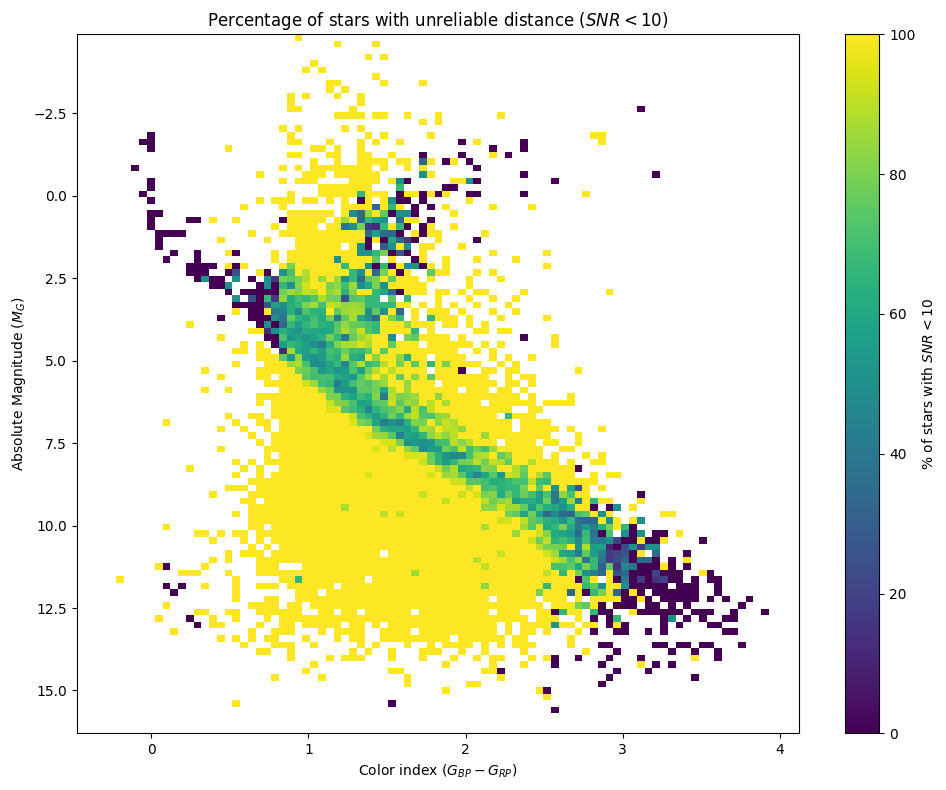

In [7]:
# Stars with unreliable distance
df_gaia["bad_distance"] = df_gaia["parallax_over_error"] < 10

color_bins = np.arange(-0.5, 4.2, 0.05)
mag_bins = np.arange(-5, 16.5, 0.2)
df_gaia["color_bin"] = pd.cut(df_gaia["bp_rp"], color_bins)
df_gaia["mag_bin"] = pd.cut(df_gaia["absolute_g"], mag_bins)

# Percentage of stars with unreliable distance 
heat = (
    df_gaia
    .groupby(["mag_bin", "color_bin"], observed=False)["bad_distance"]
    .mean()
    .unstack()
    * 100
)

x = [i.mid for i in heat.columns]
y = [i.mid for i in heat.index]

plt.figure(figsize=(10,8))

im = plt.imshow(
    heat,
    origin="lower",
    aspect="auto",
    extent=[x[0], x[-1], y[0], y[-1]],
    cmap="viridis",
    vmin=0,
    vmax=100
)

plt.gca().invert_yaxis()
plt.xlabel(r"Color index ($G_{BP}-G_{RP}$)")
plt.ylabel(r"Absolute Magnitude ($M_G$)")
plt.title("Percentage of stars with unreliable distance ($SNR<10$)")
cbar = plt.colorbar(im)
cbar.set_label("% of stars with $SNR<10$")
plt.tight_layout()
plt.show()

## Lutz-Kelker bias

Lutz and Kelker (1973) analyzed the problem of star selection by imposing a “minimum limit” on observed parallax, which introduces a systematic error. Since instruments have errors, some stars that are actually outside this limit (further away) will be overestimated and included in the sample. At the same time, some stars that should be inside (closer) will be underestimated and excluded because, at greater distances, the volume of space is much larger; there are far more stars outside waiting to “sneak in” by error than there are stars inside that might be excluded. 


Geometric analysis at the boundary ($\pi'$) shows that since the geometry of space is not symmetric (stars are uniformly distributed throughout the universe, so the number of stars per parallax interval varies drastically as $1/\pi^4$). Mathematically, this means there is an overwhelmingly larger number of stars with smaller (more distant) true parallaxes. Thus, the vast majority of stars that register as $\pi'$ come from that enormous, textured cluster of distant stars that were pushed upward by measurement noise. Consequently, the average true parallax of those stars will always be less than the measured value $\pi'$.

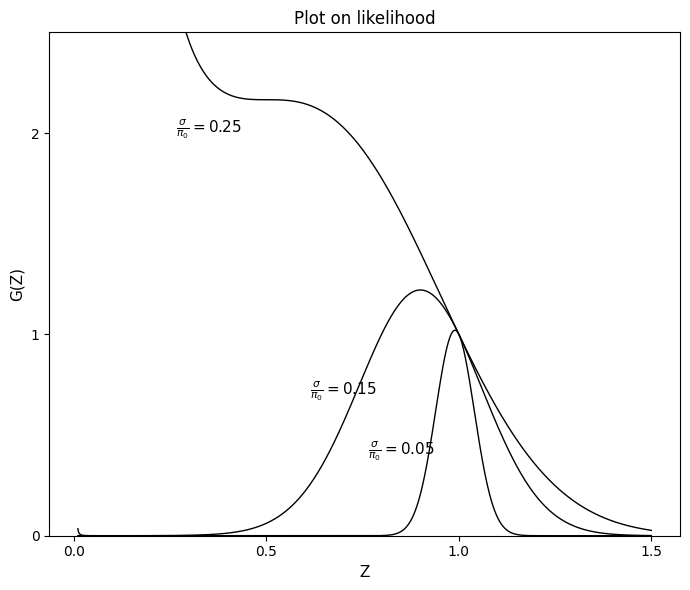

In [8]:
# Likelihood
def G(Z, s_p):
    """
    Z: X axis
    s_p: Y axis (sigma / pi_0)
    """
    # No division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        return (1 / Z**4) * np.exp(-((Z - 1)**2) / (2 * (s_p**2)))

Z = np.linspace(0.01, 1.5, 1000)
params = [0.25, 0.15, 0.05]

plt.figure(figsize=(7, 6))
for s_p in params:
    plt.plot(Z, G(Z, s_p), color='black', linewidth=1)

plt.ylim(0, 2.5)
plt.xlabel('Z', fontsize=11)
plt.ylabel('G(Z)', fontsize=11)
plt.xticks([0, 0.5, 1.0, 1.5])
plt.yticks([0, 1.0, 2.0])
plt.text(0.35, 2.0, r'$\frac{\sigma}{\pi_0}=0.25$', fontsize=11, ha='center')
plt.text(0.7, 0.7, r'$\frac{\sigma}{\pi_0}=0.15$', fontsize=11, ha='center')
plt.text(0.85, 0.4, r'$\frac{\sigma}{\pi_0}=0.05$', fontsize=11, ha='center')
plt.title(label="Plot on likelihood")
plt.tight_layout()
plt.show()